# 前置作業

## 套件

In [1]:
import pandas as pd
import re
import numpy as np
import pmdarima as pm
import mpl_tc_fonts
# from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

## 資料

欄位

In [2]:
cols = {'一.食物類': 'Food',
        '17.外食費': 'FAFH',
        '2.肉類': 'meats', '11豬肉': 'pork', '13牛肉、牛內臟': 'beef', '15雞肉': 'poultry',
        '5.水產品': 'seafood',
        '4.蛋類': 'eggs', '20雞蛋': 'egg',
        '11.乳類': 'dairy','121鮮奶': 'milk',
        '7.蔬菜': 'vegetable',
        '9.水果': 'fruit',
        '12.食用油': 'oils'
        }
ycol = 'egg'
forecast_year = 2025
reference_year = forecast_year - 1

載入資料

In [3]:
url = "https://ws.dgbas.gov.tw/001/Upload/461/relfile/11525/230543/pr0101a3m.xml"
data = pd.read_xml(url)
# 轉換日期
data["date"] = pd.to_datetime(data["TIME_PERIOD"].str.replace("M", "-", regex=False) + "-01")
# 篩選月、指數
data = data[(data.FREQ=='M') & (data.TYPE=='原始值')].copy()
# 文字處理
data['Item'] = data.Item.str.replace("(指數基期：民國110年=100)", "")

data["Item_VALUE"] = pd.to_numeric(data["Item_VALUE"], errors="coerce")

wide = (
    data.pivot_table(
        index="date",
        columns="Item",
        values="Item_VALUE",
        aggfunc="first"
    )
    .sort_index()
    .asfreq("MS")
)

data = wide[cols.keys()].rename(columns=cols).copy()
data

Item,Food,FAFH,meats,pork,beef,poultry,seafood,eggs,egg,dairy,milk,vegetable,fruit,oils
date,,,,,,,,,,,,,,
2013-01-01,83.84,86.05,79.07,76.88,72.93,83.29,76.69,95.24,97.80,90.02,86.69,72.57,84.14,92.21
2013-02-01,82.51,86.02,80.11,78.75,73.82,83.43,79.03,95.12,97.70,89.57,86.56,58.74,83.92,89.69
2013-03-01,81.26,86.23,78.07,76.57,73.34,80.79,76.30,96.86,99.77,89.85,86.69,49.70,81.65,90.84
2013-04-01,81.89,86.30,77.53,76.75,72.41,79.26,76.98,96.35,99.02,89.10,84.69,59.84,76.96,92.88
2013-05-01,83.20,86.38,76.97,76.56,72.69,77.82,77.19,87.86,88.91,90.05,86.87,71.55,78.36,92.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,118.37,118.91,122.87,131.66,123.26,114.58,116.68,121.17,119.90,104.22,102.45,109.95,138.21,120.59
2026-01-01,117.78,119.30,123.11,131.80,123.54,114.85,118.00,121.28,120.03,104.04,102.47,102.01,133.46,119.26
2026-02-01,116.95,119.51,123.18,131.88,124.48,114.52,120.05,129.44,129.78,103.69,101.61,94.09,127.12,118.85


In [4]:
df = data.sort_index().asfreq("MS").copy()
df

Item,Food,FAFH,meats,pork,beef,poultry,seafood,eggs,egg,dairy,milk,vegetable,fruit,oils
date,,,,,,,,,,,,,,
2013-01-01,83.84,86.05,79.07,76.88,72.93,83.29,76.69,95.24,97.80,90.02,86.69,72.57,84.14,92.21
2013-02-01,82.51,86.02,80.11,78.75,73.82,83.43,79.03,95.12,97.70,89.57,86.56,58.74,83.92,89.69
2013-03-01,81.26,86.23,78.07,76.57,73.34,80.79,76.30,96.86,99.77,89.85,86.69,49.70,81.65,90.84
2013-04-01,81.89,86.30,77.53,76.75,72.41,79.26,76.98,96.35,99.02,89.10,84.69,59.84,76.96,92.88
2013-05-01,83.20,86.38,76.97,76.56,72.69,77.82,77.19,87.86,88.91,90.05,86.87,71.55,78.36,92.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-12-01,118.37,118.91,122.87,131.66,123.26,114.58,116.68,121.17,119.90,104.22,102.45,109.95,138.21,120.59
2026-01-01,117.78,119.30,123.11,131.80,123.54,114.85,118.00,121.28,120.03,104.04,102.47,102.01,133.46,119.26
2026-02-01,116.95,119.51,123.18,131.88,124.48,114.52,120.05,129.44,129.78,103.69,101.61,94.09,127.12,118.85


# Model

## SARIMAX

In [5]:
y = 'Food'
# 11月底的新聞稿，只有10月CPI指數
end_date = pd.to_datetime('2026-04-1')
# 預測至下年度12月
forecast_date = end_date + pd.DateOffset(years=1, months=12-int(end_date.month))
year_avg = df.loc[:forecast_date-pd.DateOffset(years=2)].resample("YS").mean()
display(year_avg)
forecast_date

Item,Food,FAFH,meats,pork,beef,poultry,seafood,eggs,egg,dairy,milk,vegetable,fruit,oils
date,,,,,,,,,,,,,,
2013-01-01,83.991667,86.445000,78.918333,77.034167,73.980833,82.321667,78.241667,88.507500,89.741667,90.560833,87.000000,74.351667,80.823333,91.788333
2014-01-01,87.135000,89.560833,87.681667,87.795000,79.891667,90.267500,83.546667,96.994167,99.247500,91.273333,86.587500,71.747500,87.589167,94.150833
2015-01-01,89.858333,91.576667,90.515833,89.980833,85.090833,93.179167,85.451667,96.897500,97.585833,91.235000,85.743333,82.930833,88.321667,93.650000
2016-01-01,94.561667,92.932500,91.416667,90.556667,88.461667,93.430833,89.471667,98.025833,98.139167,91.535833,86.659167,101.527500,104.934167,92.860000
2017-01-01,94.213333,94.777500,93.525000,94.232500,90.520000,93.540833,93.803333,88.139167,86.320000,94.657500,91.998333,86.792500,101.541667,93.539167
2018-01-01,95.147500,96.702500,94.799167,94.400000,90.712500,96.596667,96.428333,100.428333,101.505000,98.052500,98.349167,83.867500,91.116667,96.800833
2019-01-01,96.959167,98.196667,94.995000,95.271667,92.666667,95.304167,97.414167,99.026667,99.443333,99.141667,99.074167,90.537500,94.845833,97.384167
2020-01-01,97.610000,99.135000,96.104167,95.512500,94.366667,97.100833,98.161667,94.163333,93.180833,100.073333,100.539167,87.705833,95.633333,97.353333
2021-01-01,100.000833,100.000000,99.999167,100.000833,99.999167,100.000000,99.997500,99.999167,100.000000,100.000000,99.999167,99.999167,100.000000,100.000833


Timestamp('2027-12-01 00:00:00')

In [6]:
def fit_tb1957_auto_arima(y, end_date=end_date, years=12):
    """
    使用 pmdarima auto_arima 配適模型。
    ----------------------------------------
    y: 某品項的時間序列資料(DataFrame, index為YM)
    end_date: 使用資料的迄點
    years: 使用資料年數
    """
    y =  y.copy()
    #  only the previous 12 years of data are used
    start_date = end_date - pd.DateOffset(months=years*12-1)
    y_train = y.loc[start_date:end_date]
    model = pm.auto_arima(
        y_train,
        m=12,
        start_p=0, max_p=12,
        start_q=0, max_q=12,
        max_d=4,
        seasonal=True,
        start_P=0, max_P=2, 
        start_Q=0, max_Q=2, 
        max_D=1,
        information_criterion="bic",
        trace=True, error_action='ignore', suppress_warnings=True,
        # # Whether to use the stepwise algorithm outlined in Hyndman and Khandakar (2008) to identify the optimal model parameters.
        # stepwise=False,
        # # Maximum value of p+q+P+Q if model selection is not stepwise.
        # max_order=None,
        # # The maximum number of function evaluations.
        # maxiter=None
    )
    return model
    
model = fit_tb1957_auto_arima(y=df[y])

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=421.428, Time=0.04 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=414.658, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=413.195, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=422.537, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=414.388, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=408.012, Time=0.13 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=410.745, Time=0.04 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : BIC=412.966, Time=0.37 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : BIC=412.969, Time=0.34 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : BIC=411.622, Time=0.14 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : BIC=409.529, Time=0.08 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : BIC=416.836, Time=0.43 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=410.544, Time=0.15 sec
 ARIMA(1,1,1)(1,0,1)[12] intercept   : BIC=409.809, Time=0.16 sec
 ARIMA(0,1,2)(1,0,1)[12] intercep

## 蒙地卡羅模擬

In [7]:
def simulate_arima_paths(model, end_date=end_date, n_sim=10000, seed=1):
    """
    使用 pmdarima auto_arima 配好的模型，
    透過 statsmodels SARIMAXResults.simulate() 做蒙地卡羅模擬。
    ----------------------------------------
    model: pm.auto_arima() 回傳的模型
    end_date: 使用資料的迄點
    n_sim: 模擬路徑數
    """
    # steps: 要模擬幾個月 (預測迄點 - 使用資料迄點)
    steps = (forecast_date.to_period('M') - end_date.to_period('M')).n
    sim = model.arima_res_.simulate(
        nsimulations=steps,
        repetitions=n_sim,
        anchor="end",
        random_state=seed,
    )
    return sim
sim_df = simulate_arima_paths(model, end_date=end_date, n_sim=10000, seed=1)
sim_df

y                                                  \
                  0           1           2           3           4      
2026-05-01  117.309220  117.580677  117.947220  117.086174  117.451777   
2026-06-01  118.058798  116.136682  116.651942  117.237479  117.054610   
2026-07-01  118.695662  115.880974  116.868849  116.574984  116.941818   
2026-08-01  119.260255  117.460150  118.822901  118.039692  117.552725   
2026-09-01  119.633812  116.886418  119.624266  118.128464  118.567769   
2026-10-01  119.604774  116.991291  119.239669  118.878499  118.333191   
2026-11-01  120.785450  117.397297  117.682795  119.136832  117.744184   
2026-12-01  119.152772  116.976365  116.667978  117.296396  117.364199   
2027-01-01  118.833194  116.292671  116.650180  115.816007  116.515754   
2027-02-01  120.355903  117.300068  116.154443  116.499050  117.835585   
2027-03-01  120.982084  117.892023  116.128585  116.817428  118.763512   
2027-04-01  122.836992  117.579743  117.645825  116.657913  118.244883   
2027-05-01  123.071660  117.521588  119.313795  115.959770  117.039960   
2027-06-01  122.548936  115.706670  116.609735  115.923617  116.379398   
2027-07-01  122.358113  114.991977  116.676269  115.466173  117.404026   
2027-08-01  123.001846  117.486048  118.780051  117.791606  118.160519   
2027-09-01  123.441041  119.149141  119.221247  117.945593  118.177044   
2027-10-01  125.011372  119.313002  120.786409  118.401172  119.085004   
2027-11-01  125.513002  118.111109  121.834160  119.730939  119.370438   
2027-12-01  124.424991  116.048350  120.473374  118.626386  117.512440   

                                                                        ...  \
                  5           6           7           8           9     ...   
2026-05-01  116.934507  117.718997  117.756150  118.351776  117.172431  ...   
2026-06-01  118.431951  117.527897  116.116205  117.647067  118.042141  ...   
2026-07-01  120.565735  119.573637  116.860115  116.577747  119.553370  ...   
2026-08-01  121.159678  120.816099  118.547988  119.445454  121.095720  ...   
2026-09-01  122.100641  120.825829  116.249174  120.725547  122.138652  ...   
2026-10-01  125.026885  122.476453  116.269959  121.307403  121.568026  ...   
2026-11-01  125.733031  122.963137  117.481862  122.526753  121.257797  ...   
2026-12-01  124.754969  122.966750  117.471442  122.366505  123.292731  ...   
2027-01-01  123.909523  122.385981  117.781479  120.288039  124.527796  ...   
2027-02-01  122.824391  122.010623  117.921919  119.723648  124.242350  ...   
2027-03-01  122.424358  121.802680  117.900119  120.232570  124.221913  ...   
2027-04-01  121.977398  121.495608  117.605687  119.660322  123.052872  ...   
2027-05-01  121.007381  121.413486  117.537728  119.250362  124.703640  ...   
2027-06-01  121.941781  121.727336  117.607425  119.889528  125.628887  ...   
2027-07-01  123.572954  123.718873  117.582591  120.591487  126.179321  ...   
2027-08-01  124.288405  125.552498  119.682704  121.578974  127.545503  ...   
2027-09-01  124.896089  126.141677  119.478958  122.364003  127.478596  ...   
2027-10-01  126.774784  128.186600  119.599532  123.929326  127.393460  ...   
2027-11-01  125.710879  129.545190  119.934927  122.644923  126.690492  ...   
2027-12-01  125.338465  129.427667  119.218197  120.583427  126.269906  ...   

                                                                        \
                  9990        9991        9992        9993        9994   
2026-05-01  117.785156  117.022305  116.663697  117.247055  116.864755   
2026-06-01  117.441377  115.961474  117.008103  116.832891  116.509907   
2026-07-01  117.643806  114.532329  117.631751  115.858719  117.167233   
2026-08-01  119.646392  116.835640  117.861410  116.691398  119.532981   
2026-09-01  121.046771  119.075232  120.267937  118.025245  120.725050   
2026-10-01  121.142228  117.167007  120.718367  118.937757  120.805223   
2026-11-01  119.552693  116.680215  120.419233  118.387164  1

合併歷史(近12年)資料

In [8]:
def combine_training_history_and_simulation(y=df[y], sim_df=sim_df, end_date=end_date, years=12):
    y = y.copy()

    end_date = pd.to_datetime(end_date)
    start_date = end_date - pd.DateOffset(months=years * 12 - 1)

    hist = y.loc[start_date:end_date].dropna()

    hist_df = pd.DataFrame(
        np.repeat(hist.to_numpy().reshape(-1, 1), sim_df.shape[1], axis=1),
        index=hist.index,
        columns=sim_df.columns,
    )

    combined_df = pd.concat([hist_df, sim_df], axis=0)

    return combined_df
combined_df = combine_training_history_and_simulation(y=df[y], sim_df=sim_df, end_date=end_date, years=12)
combined_df

y                                                  \
                  0           1           2           3           4      
2014-05-01   86.790000   86.790000   86.790000   86.790000   86.790000   
2014-06-01   86.780000   86.780000   86.780000   86.780000   86.780000   
2014-07-01   86.530000   86.530000   86.530000   86.530000   86.530000   
2014-08-01   88.350000   88.350000   88.350000   88.350000   88.350000   
2014-09-01   88.970000   88.970000   88.970000   88.970000   88.970000   
...                ...         ...         ...         ...         ...   
2027-08-01  123.001846  117.486048  118.780051  117.791606  118.160519   
2027-09-01  123.441041  119.149141  119.221247  117.945593  118.177044   
2027-10-01  125.011372  119.313002  120.786409  118.401172  119.085004   
2027-11-01  125.513002  118.111109  121.834160  119.730939  119.370438   
2027-12-01  124.424991  116.048350  120.473374  118.626386  117.512440   

                                                                        ...  \
                  5           6           7           8           9     ...   
2014-05-01   86.790000   86.790000   86.790000   86.790000   86.790000  ...   
2014-06-01   86.780000   86.780000   86.780000   86.780000   86.780000  ...   
2014-07-01   86.530000   86.530000   86.530000   86.530000   86.530000  ...   
2014-08-01   88.350000   88.350000   88.350000   88.350000   88.350000  ...   
2014-09-01   88.970000   88.970000   88.970000   88.970000   88.970000  ...   
...                ...         ...         ...         ...         ...  ...   
2027-08-01  124.288405  125.552498  119.682704  121.578974  127.545503  ...   
2027-09-01  124.896089  126.141677  119.478958  122.364003  127.478596  ...   
2027-10-01  126.774784  128.186600  119.599532  123.929326  127.393460  ...   
2027-11-01  125.710879  129.545190  119.934927  122.644923  126.690492  ...   
2027-12-01  125.338465  129.427667  119.218197  120.583427  126.269906  ...   

                                                                        \
                  9990        9991        9992        9993        9994   
2014-05-01   86.790000   86.790000   86.790000   86.790000   86.790000   
2014-06-01   86.780000   86.780000   86.780000   86.780000   86.780000   
2014-07-01   86.530000   86.530000   86.530000   86.530000   86.530000   
2014-08-01   88.350000   88.350000   88.350000   88.350000   88.350000   
2014-09-01   88.970000   88.970000   88.970000   88.970000   88.970000   
...                ...         ...         ...         ...         ...   
2027-08-01  122.161690  119.286090  121.109642  115.481998  119.833144   
2027-09-01  121.886793  120.144068  123.217257  115.562645  121.743932   
2027-10-01  121.297942  120.298221  122.567873  117.361802  121.726122   
2027-11-01  120.347845  121.028423  123.139005  118.611907  122.115748   
2027-12-01  120.285840  120.159284  123.315031  118.604128  122.595395   

                                                                        
                  9995        9996        9997        9998        9999  
2014-05-01   86.790000   86.790000   86.790000   86.790000   86.790000  
2014-06-01   86.780000   86.780000   86.780000   86.780000   86.780000  
2014-07-01   86.530000   86.530000   86.530000   86.530000   86.530000  
2014-08-01   88.350000   88.350000   88.350000   88.350000   88.350000  
2014-09-01   88.970000   88.970000   88.970000   88.970000   88.970000  
...                ...         ...         ...         ...         ...  
2027-08-01  121.458852  122.116120  124.148654  122.187356  123.502996  
2027-09-01  122.460964  122.713612  125.402024  120.742734  123.809127  
2027-10-01  124.093049  122.697853  126.272807  120.540496  124.446177  
2027-11-01  123.791078  122.713769  125.839618  121.143160  124.096521  
2027-12-01  123.762617  121.247165  126.410968  121.639664  122.212805  

[164 rows x 10000 columns]

In [9]:
q0025 = combined_df.quantile(0.025, axis=1)
q0500 = combined_df.quantile(0.5, axis=1)
q0975 = combined_df.quantile(0.975, axis=1)

summary_month_df = pd.DataFrame([q0025, q0500, q0975]).T
summary_month_df = summary_month_df.tail(48).copy()
summary_month_df

,0.025,0.500,0.975
2024-01-01,112.240000,112.240000,112.240000
2024-02-01,112.160000,112.160000,112.160000
2024-03-01,111.510000,111.510000,111.510000
2024-04-01,111.630000,111.630000,111.630000
2024-05-01,112.780000,112.780000,112.780000
2024-06-01,112.830000,112.830000,112.830000
2024-07-01,113.130000,113.130000,113.130000
2024-08-01,115.270000,115.270000,115.270000
2024-09-01,115.740000,115.740000,115.740000
2024-10-01,116.390000,116.390000,116.390000


# 合併

In [10]:
# 設定品項
y = 'eggs'
# 設定日期
end_date = pd.to_datetime('2025-12-1')
forecast_date = pd.to_datetime('2026-12-1')
n = 5

def get_result(y, end_date, forecast_date, n):
    # 多個月
    summary_list = []
    for _ in range(n):  
        model = fit_tb1957_auto_arima(y=df[y], end_date=end_date)
        sim_df = simulate_arima_paths(model, end_date=end_date, n_sim=10000, seed=1)
        combined_df = combine_training_history_and_simulation(y=df[y], sim_df=sim_df, end_date=end_date, years=12)

        annual_avg = combined_df.loc[str(forecast_date.year)].mean(axis=0)
        q025, q500, q975 = annual_avg.quantile(0.025), annual_avg.quantile(0.500), annual_avg.quantile(0.975)
        summary_list.append({"month": end_date,
                    "lower_95": q025, "median": q500, "upper_95": q975
                })
        end_date = end_date + pd.DateOffset(months=1)

    # 最後一個月的預測
    q0025 = combined_df.quantile(0.025, axis=1)
    q0500 = combined_df.quantile(0.5, axis=1)
    q0975 = combined_df.quantile(0.975, axis=1)
    summary_month_df = pd.DataFrame([q0025, q0500, q0975]).T
    summary_month_df = summary_month_df.tail(48).copy()

    # 實際年增率
    try:
        base_index = year_avg.loc[str(forecast_date.year-1), y].values[0]
        t_index = year_avg.loc[str(forecast_date.year), y].values[0]
        actual_yoy = (t_index / base_index - 1) * 100
    except:
        base_index = year_avg.loc[str(forecast_date.year-1), y].values[0]
        actual_yoy = None
                
    summary_df = pd.DataFrame(summary_list).set_index('month')
    summary_yoy_df = summary_df / base_index * 100 - 100
    return summary_df, summary_yoy_df, actual_yoy, summary_month_df

summary_df, summary_yoy_df, actual_yoy, summary_month_d = get_result(y=y, end_date=end_date, forecast_date=forecast_date, n=n)

Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=892.669, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=892.081, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=895.118, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=887.908, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=887.366, Time=0.03 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : BIC=883.392, Time=0.09 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : BIC=878.841, Time=0.17 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=874.869, Time=0.09 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=890.799, Time=0.04 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : BIC=878.765, Time=0.21 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : BIC=889.358, Time=0.14 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : BIC=883.872, Time=0.32 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=879.758, Time=0.12 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=879.737, Time=0.11 sec
 ARIMA(1,1,1)(1,0,1)[12] intercep

In [11]:
# display(summary_month_df)
# display(summary_df)
display(summary_yoy_df)

,lower_95,median,upper_95
month,,,
2025-12-01,-8.744538,7.726550,24.929840
2026-01-01,-8.295994,6.819541,21.652110
2026-02-01,-0.690804,12.359996,25.370473
2026-03-01,-7.722345,3.671879,15.097347
2026-04-01,-7.417149,2.276674,11.931763


# 繪圖

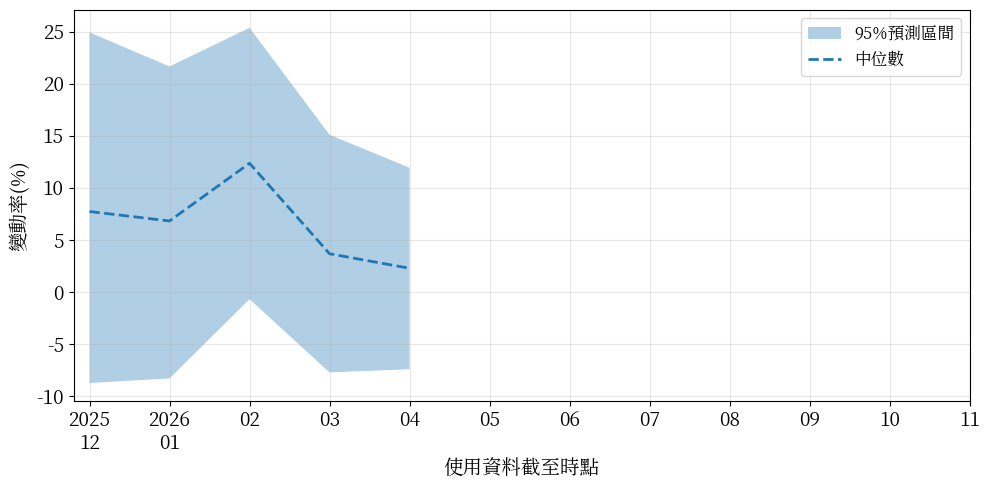

In [12]:
def plot_result(summary_yoy_df, actual_yoy=actual_yoy):
    plot_df = summary_yoy_df.copy()
    start_date = summary_yoy_df.index.min()
    months = pd.date_range(start_date, start_date+pd.DateOffset(months=11), freq='MS')
    for m in months:
        if m not in summary_yoy_df.index:
            plot_df.loc[m] = np.nan            
    plot_df["label"] = [f"{forecast_date.year-1}\n12", f"{forecast_date.year}\n01", "02", "03", "04", "05", "06",
                        "07", "08", "09", "10", "11"]
    plot_df["x"] = range(len(plot_df))
    if actual_yoy != None:
        plot_df["actual"] = actual_yoy

    fig, ax = plt.subplots(figsize=(10, 5))

    ax.fill_between(
        plot_df["x"],
        plot_df["lower_95"],
        plot_df["upper_95"],
        alpha=0.35,
        label="95%預測區間"
    )

    ax.plot(
        plot_df["x"],
        plot_df["median"],
        linestyle="--",
        linewidth=2,
        label="中位數"
    )

    if actual_yoy != None:
        ax.plot(
            plot_df["x"],
            plot_df["actual"],
            linewidth=1.5,
            label="實際年變動率",
            color='black'
        )

    ax.set_xticks(plot_df["x"])
    ax.set_xticklabels(plot_df["label"], fontsize=14)
    ax.tick_params(axis="y", labelsize=14)

    ax.set_ylabel("變動率(%)", fontsize=14)
    ax.set_xlabel("使用資料截至時點", fontsize=14)

    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)

    plt.tight_layout()
    # savepath = f"C:/Users/SO002/Desktop/FPO/outputs/backtest/{ycol}.png"
    # plt.savefig(savepath)
    plt.show()

plot_result(summary_yoy_df, actual_yoy=actual_yoy)

# 全部品項實作

In [13]:
cols = {'一.食物類': 'Food',
        '17.外食費': 'FAFH',
        '2.肉類': 'meats', '11豬肉': 'pork', '13牛肉、牛內臟': 'beef', '15雞肉': 'poultry',
        '5.水產品': 'seafood',
        '4.蛋類': 'eggs', '20雞蛋': 'egg',
        '11.乳類': 'dairy','121鮮奶': 'milk',
        '7.蔬菜': 'vegetable',
        '9.水果': 'fruit',
        '12.食用油': 'oils'
        }

--------------------------------------開始 Food 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=438.326, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=434.683, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=433.257, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=439.749, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=432.056, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=431.187, Time=0.04 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : BIC=428.081, Time=0.10 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : BIC=432.806, Time=0.18 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=inf, Time=0.39 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : BIC=429.895, Time=0.08 sec
 ARIMA(1,1,1)(2,0,0)[12] intercept   : BIC=429.662, Time=0.19 sec
 ARIMA(0,1,2)(2,0,0)[12] intercept   : BIC=421.855, Time=0.12 sec
 ARIMA(0,1,2)(1,0,0)[12] intercept   : BIC=426.779, Time=0.05 sec
 ARIMA(0,1,2)(2,

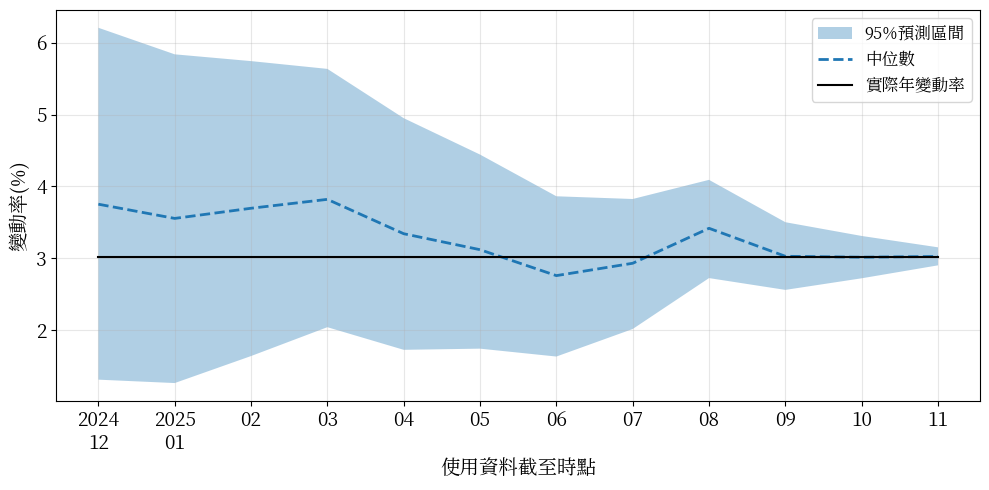

--------------------------------------開始 FAFH 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=-12.931, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=-95.800, Time=0.09 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=-76.064, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=68.512, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=-96.824, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=-95.220, Time=0.08 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=-94.218, Time=0.22 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : BIC=-91.972, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=-92.029, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=-77.552, Time=0.03 sec
 ARIMA(2,1,1)(0,0,0)[12] intercept   : BIC=-89.053, Time=0.07 sec
 ARIMA(1,1,0)(0,0,0)[12]             : BIC=-89.607, Time=0.02 sec

Best model:  ARIMA(1,1,0)(0,0,0)[12] intercept
Total fit time: 0.718 seconds
P

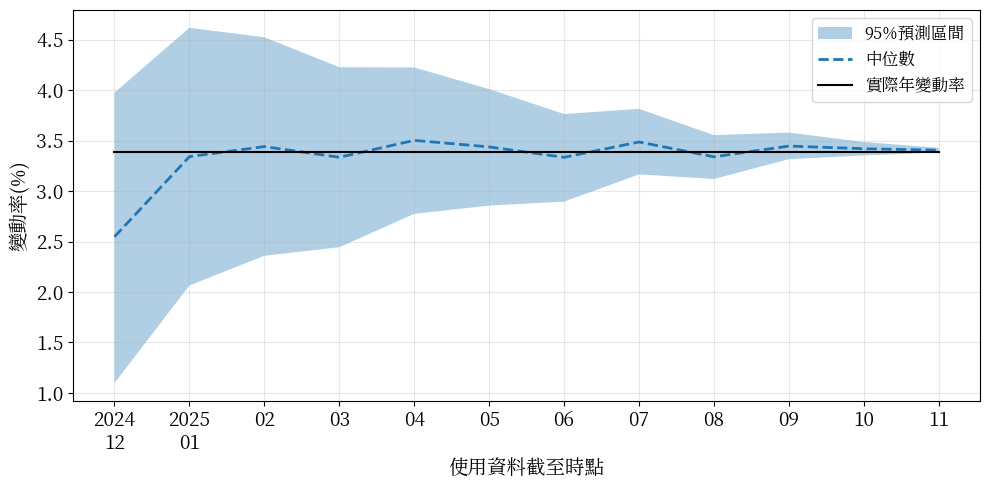

--------------------------------------開始 meats 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=343.642, Time=0.03 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=342.751, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=339.485, Time=0.10 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=354.467, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=334.848, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=339.359, Time=0.08 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=342.014, Time=0.42 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=339.805, Time=0.06 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : BIC=339.793, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=337.907, Time=0.03 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : BIC=343.176, Time=0.09 sec
 ARIMA(0,1,1)(0,0,0)[12]             : BIC=339.947, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[12] intercept
Total fit time: 1.033 seconds

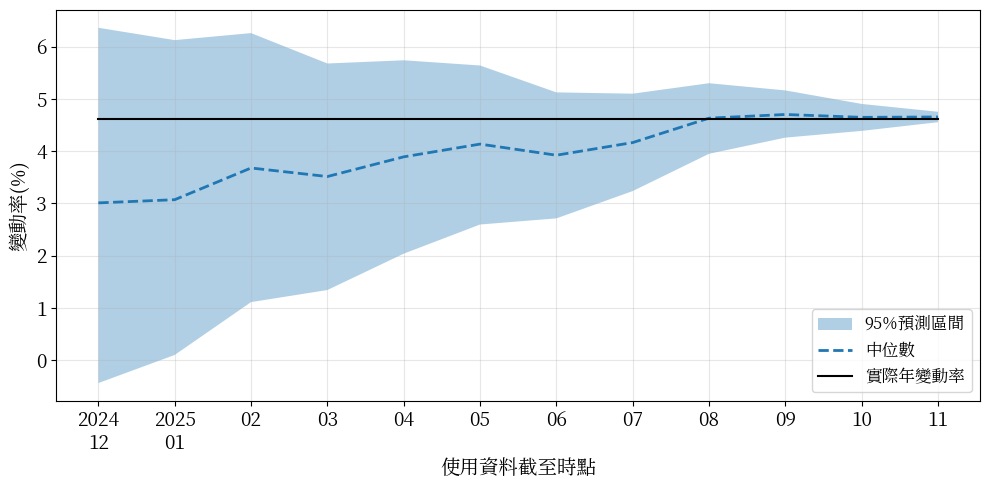

--------------------------------------開始 pork 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=490.870, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=498.816, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=498.235, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=493.975, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=495.757, Time=0.07 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=495.771, Time=0.07 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=499.036, Time=0.17 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=494.041, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=493.483, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=498.117, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 0.603 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=489.733, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12

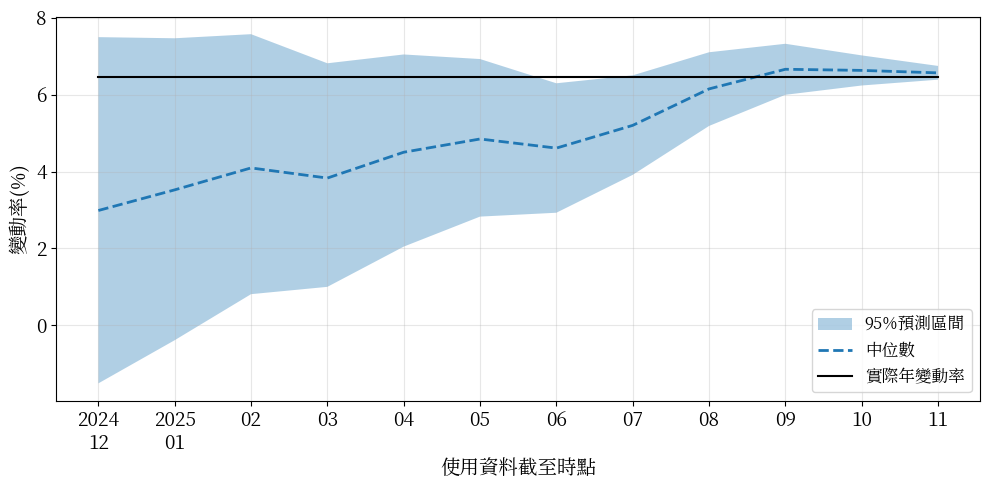

--------------------------------------開始 beef 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=316.107, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=324.013, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=323.733, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=335.672, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=320.113, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=319.976, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=323.631, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=319.726, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=319.535, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=324.387, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 0.325 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=315.932, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12

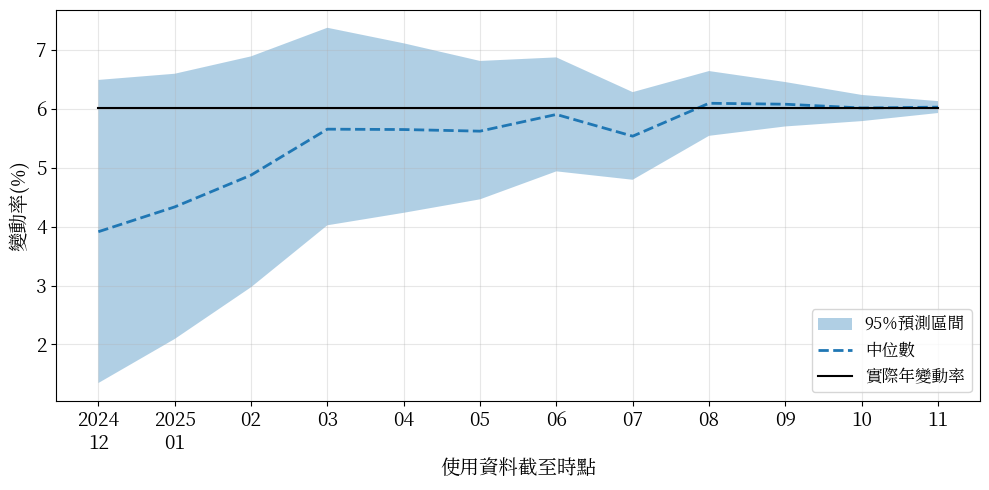

--------------------------------------開始 poultry 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=468.180, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=447.878, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=450.491, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=467.416, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=450.894, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=449.334, Time=0.22 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=446.771, Time=0.14 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=449.807, Time=0.07 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=451.205, Time=0.42 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=450.850, Time=0.41 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=452.566, Time=0.21 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=inf, Time=1.17 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=456.397, Time=0.12 sec
 ARIMA(2,1,0)

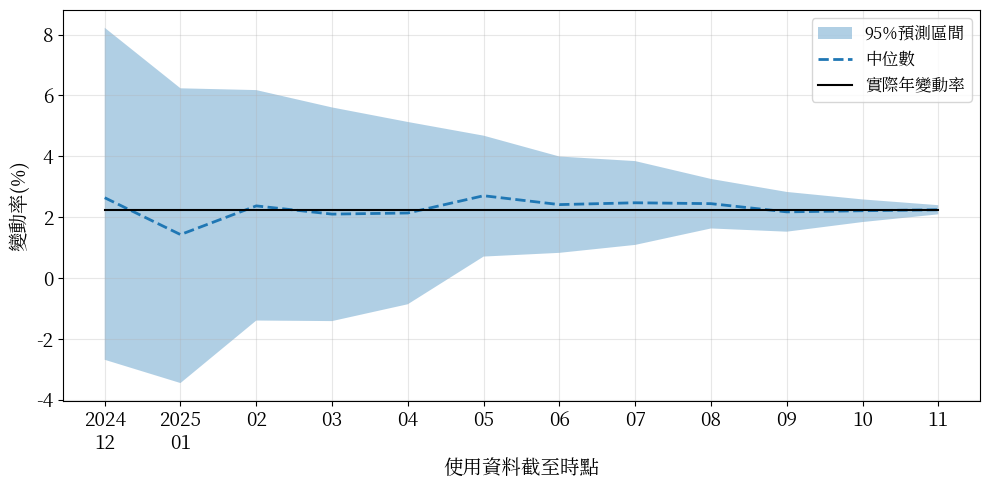

--------------------------------------開始 seafood 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=491.501, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=464.963, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=468.958, Time=0.08 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=492.417, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=494.225, Time=0.03 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=451.966, Time=0.25 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=430.362, Time=0.54 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=428.161, Time=0.32 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=476.025, Time=0.07 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=426.573, Time=0.53 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=480.896, Time=0.28 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=inf, Time=0.90 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : BIC=429.826, Time=0.49 sec
 ARIMA(2,1,0)

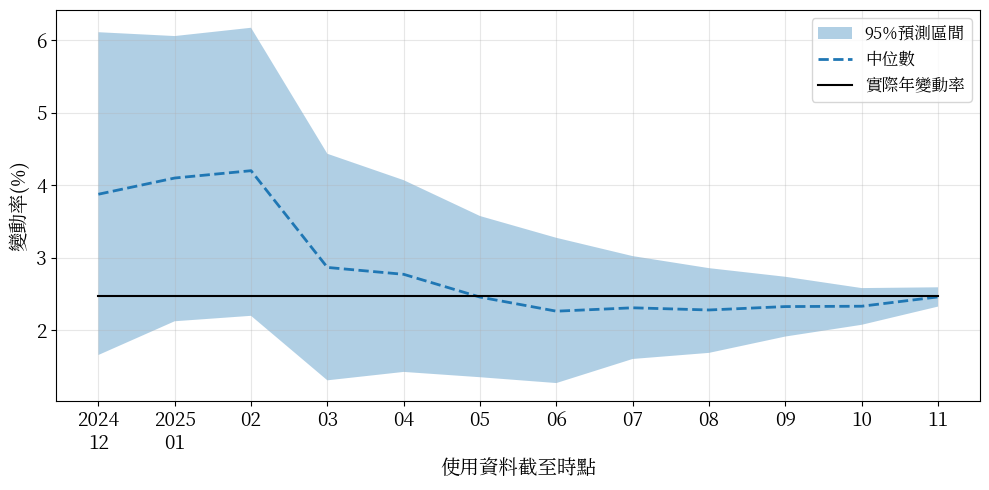

--------------------------------------開始 eggs 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=885.392, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=885.390, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=887.604, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=880.479, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=880.874, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=883.598, Time=0.04 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=888.661, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=888.049, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=inf, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 0.408 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=885.912, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] interc

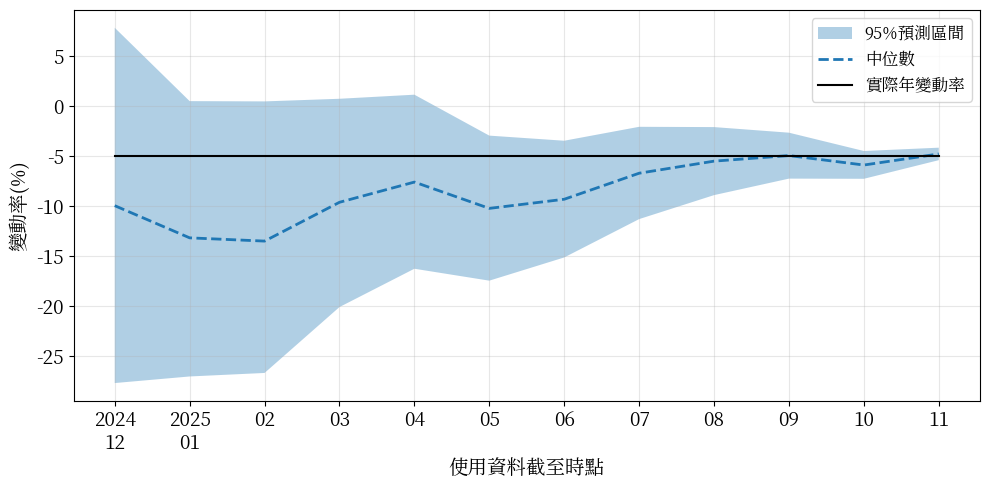

--------------------------------------開始 egg 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=938.285, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=938.257, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=940.570, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=933.334, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=933.669, Time=0.04 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=936.449, Time=0.05 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=941.727, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=941.147, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=inf, Time=0.06 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 0.438 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=938.778, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] interce

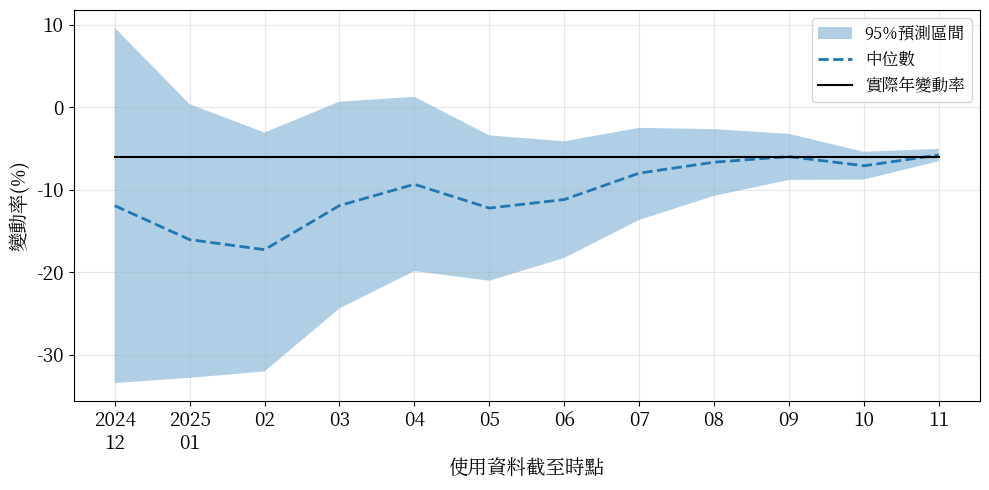

--------------------------------------開始 dairy 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=308.645, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=303.965, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=308.946, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=306.527, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=313.560, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=306.428, Time=0.14 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=301.912, Time=0.27 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=308.512, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=inf, Time=0.56 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=inf, Time=0.55 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=306.202, Time=0.15 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=inf, Time=0.73 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.23 sec
 ARIMA(2,1,0)(1,0,1)[12] in

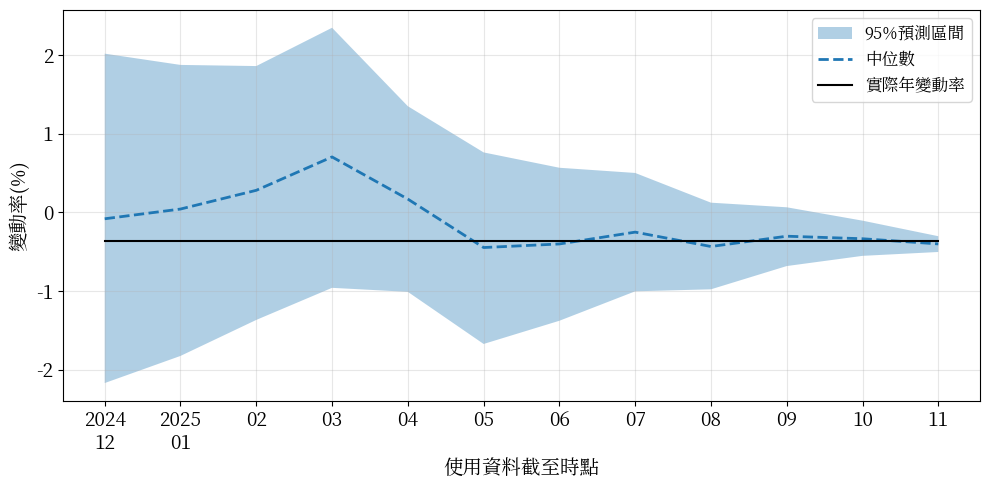

--------------------------------------開始 milk 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=496.256, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=486.247, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=494.104, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=492.298, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=500.315, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=487.533, Time=0.14 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=483.417, Time=0.14 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=493.836, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=inf, Time=0.69 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=inf, Time=0.65 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=489.818, Time=0.15 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=492.870, Time=0.37 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=482.665, Time=0.09 sec
 ARIMA(0,1,0)(0,0,1)

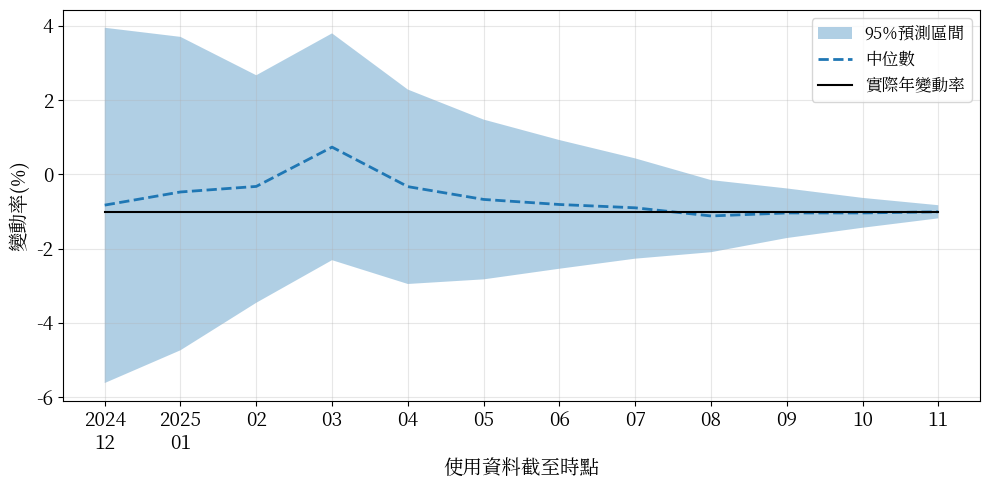

--------------------------------------開始 vegetable 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=1095.721, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=1094.870, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=1095.119, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=1090.988, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=1093.541, Time=0.05 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=1095.612, Time=0.04 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.20 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=1094.870, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=1093.863, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=1098.765, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12]          
Total fit time: 0.496 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=1098.072, Time=0.01 sec
 ARIMA(1,1,0

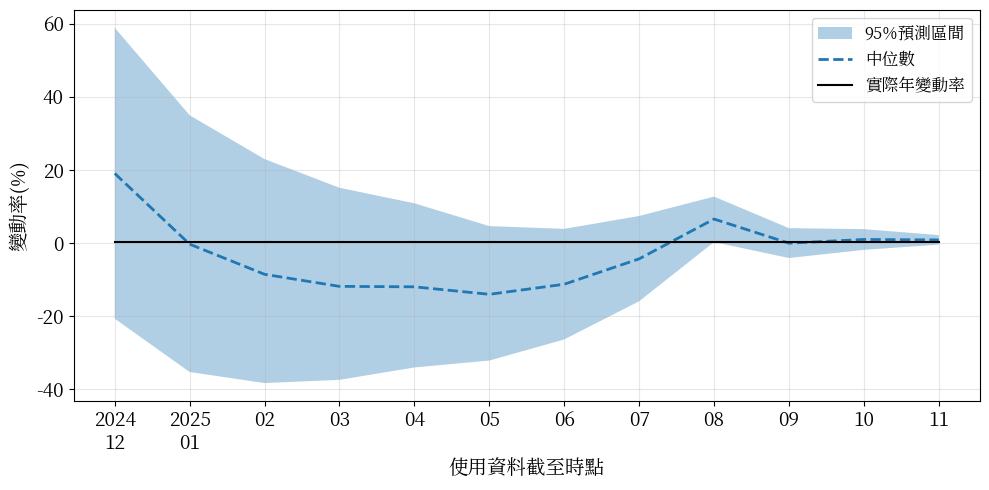

--------------------------------------開始 fruit 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=876.577, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=873.176, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=869.845, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=872.393, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=866.364, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=869.059, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=inf, Time=0.33 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=870.917, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : BIC=870.700, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=870.242, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : BIC=inf, Time=0.11 sec
 ARIMA(0,1,1)(0,0,0)[12]             : BIC=861.863, Time=0.01 sec
 ARIMA(0,1,1)(1,0,0)[12]             : BIC=864.472, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1

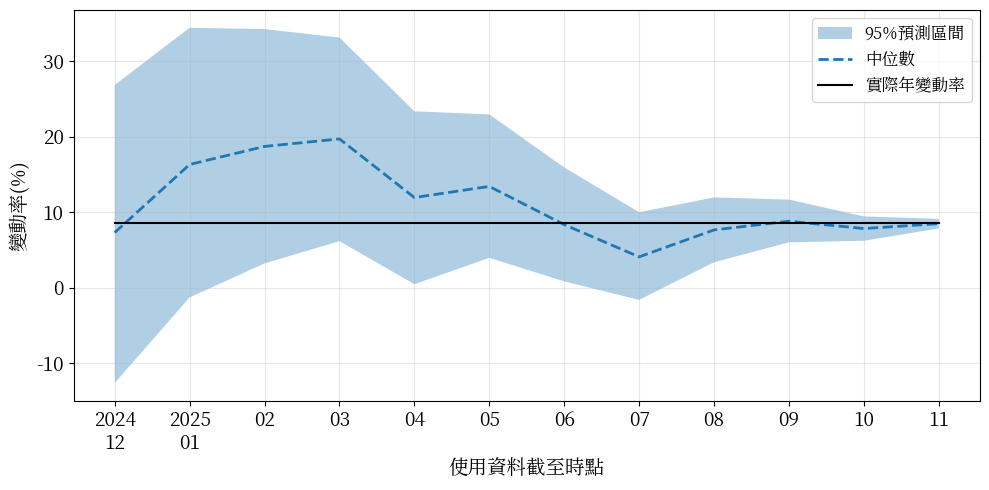

--------------------------------------開始 oils 回測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,2,0)(0,0,0)[12]             : BIC=593.496, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : BIC=556.042, Time=0.03 sec
 ARIMA(0,2,1)(0,0,1)[12]             : BIC=480.282, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[12]             : BIC=476.013, Time=0.02 sec
 ARIMA(0,2,1)(1,0,0)[12]             : BIC=479.823, Time=0.06 sec
 ARIMA(0,2,1)(1,0,1)[12]             : BIC=inf, Time=0.13 sec
 ARIMA(1,2,1)(0,0,0)[12]             : BIC=471.605, Time=0.03 sec
 ARIMA(1,2,1)(1,0,0)[12]             : BIC=476.131, Time=0.06 sec
 ARIMA(1,2,1)(0,0,1)[12]             : BIC=476.300, Time=0.08 sec
 ARIMA(1,2,1)(1,0,1)[12]             : BIC=inf, Time=0.18 sec
 ARIMA(1,2,0)(0,0,0)[12]             : BIC=551.269, Time=0.01 sec
 ARIMA(2,2,1)(0,0,0)[12]             : BIC=467.556, Time=0.03 sec
 ARIMA(2,2,1)(1,0,0)[12]             : BIC=471.482, Time=0.07 sec
 ARIMA(2,2,1)(0,0,1)

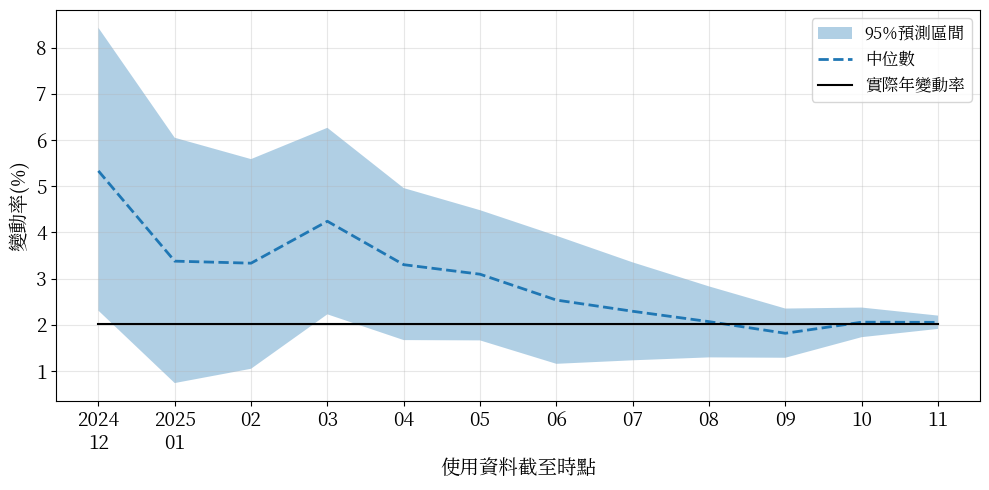

In [14]:
# 設定日期
end_date = pd.to_datetime('2024-12-1')
forecast_date = pd.to_datetime('2025-12-1')
n = 12
for item in cols.values():
    print(f'--------------------------------------開始 {item} 回測--------------------------------------')
    summary_df, summary_yoy_df, actual_yoy, summary_month_d = get_result(y=item, end_date=end_date, forecast_date=forecast_date, n=n)
    plot_result(summary_yoy_df, actual_yoy=actual_yoy)

--------------------------------------開始 Food 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=420.690, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=414.695, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=413.401, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=423.201, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=414.834, Time=0.02 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=409.955, Time=0.17 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=411.149, Time=0.04 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : BIC=inf, Time=0.56 sec
 ARIMA(0,1,1)(1,0,2)[12] intercept   : BIC=inf, Time=0.57 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : BIC=413.326, Time=0.14 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : BIC=412.312, Time=0.09 sec
 ARIMA(0,1,1)(2,0,2)[12] intercept   : BIC=inf, Time=0.66 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.16 sec
 ARIMA(1,1,1)(1,0,1)[12] int

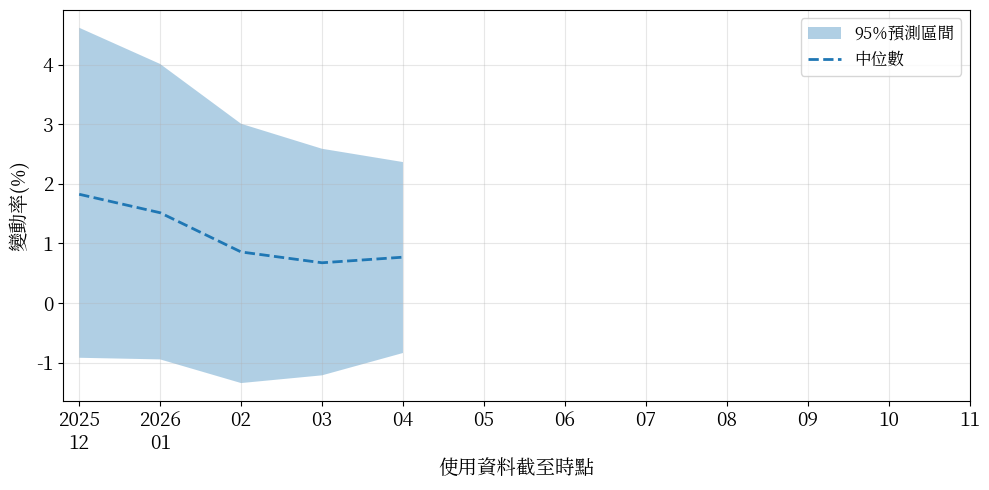

--------------------------------------開始 FAFH 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,2,0)(0,0,0)[12]             : BIC=-82.457, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : BIC=-79.827, Time=0.05 sec
 ARIMA(0,2,1)(0,0,1)[12]             : BIC=-80.371, Time=0.05 sec
 ARIMA(0,2,0)(1,0,0)[12]             : BIC=-82.192, Time=0.03 sec
 ARIMA(0,2,0)(0,0,1)[12]             : BIC=-80.922, Time=0.04 sec
 ARIMA(0,2,0)(1,0,1)[12]             : BIC=-84.927, Time=0.11 sec
 ARIMA(0,2,0)(2,0,1)[12]             : BIC=-80.079, Time=0.35 sec
 ARIMA(0,2,0)(1,0,2)[12]             : BIC=-80.068, Time=0.47 sec
 ARIMA(0,2,0)(0,0,2)[12]             : BIC=-80.211, Time=0.14 sec
 ARIMA(0,2,0)(2,0,0)[12]             : BIC=-82.246, Time=0.06 sec
 ARIMA(0,2,0)(2,0,2)[12]             : BIC=-75.019, Time=0.34 sec
 ARIMA(1,2,0)(1,0,1)[12]             : BIC=-83.086, Time=0.14 sec
 ARIMA(0,2,1)(1,0,1)[12]             : BIC=-85.140, Time=0.12 sec
 ARIMA(0,2,1

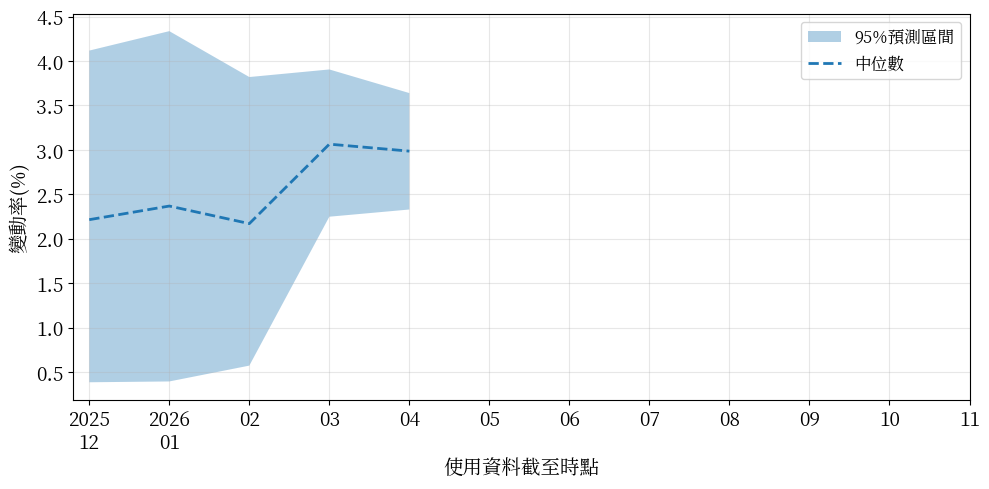

--------------------------------------開始 meats 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=325.875, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=326.204, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=320.573, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=339.660, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=315.614, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=320.573, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=324.680, Time=0.15 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=320.117, Time=0.03 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : BIC=318.790, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=321.477, Time=0.01 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : BIC=320.057, Time=0.04 sec
 ARIMA(0,1,1)(0,0,0)[12]             : BIC=321.710, Time=0.02 sec

Best model:  ARIMA(0,1,1)(0,0,0)[12] intercept
Total fit time: 0.446 seconds

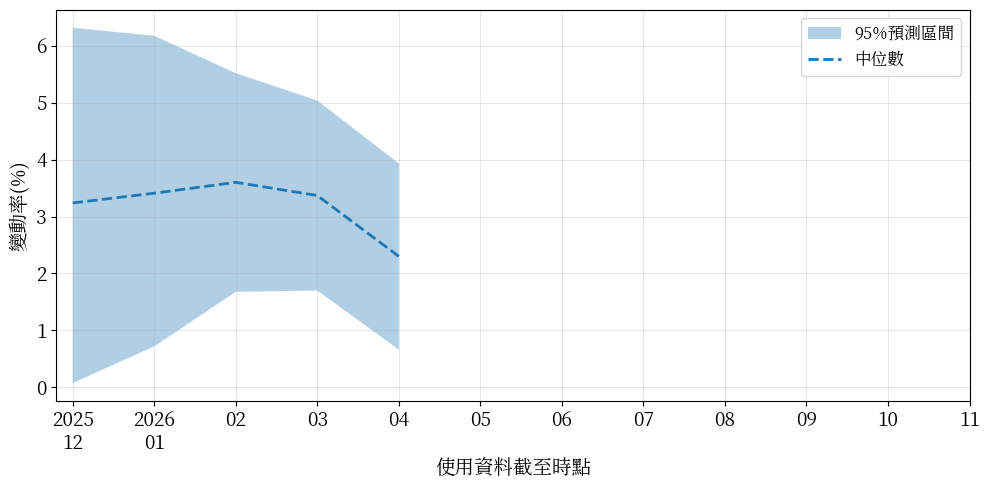

--------------------------------------開始 pork 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=495.453, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=501.722, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=500.781, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=501.493, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=499.808, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=499.875, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=502.636, Time=0.11 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=497.145, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=496.075, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=500.649, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 0.316 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=494.417, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12

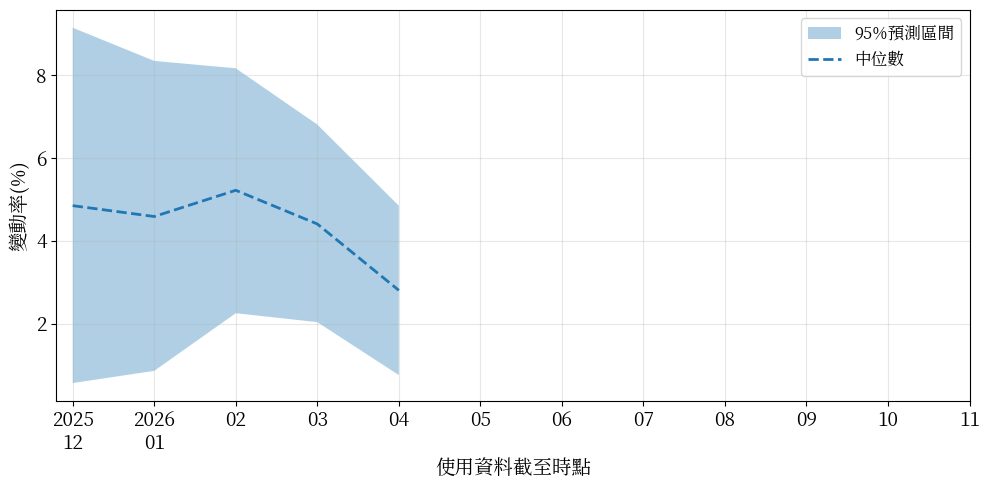

--------------------------------------開始 beef 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=306.960, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=316.364, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=316.272, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=330.453, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=311.888, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=311.881, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.23 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=311.462, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=311.387, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=316.254, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[12] intercept
Total fit time: 0.482 seconds
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=305.045, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] in

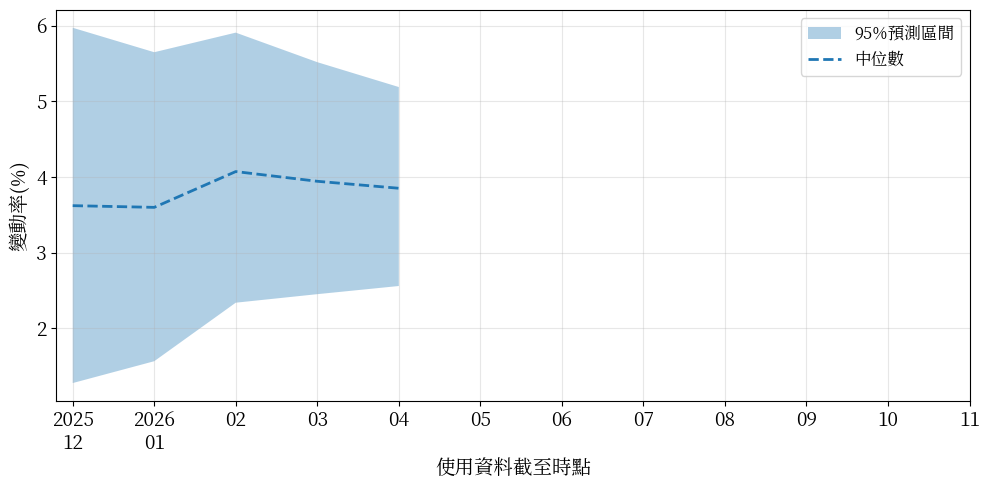

--------------------------------------開始 poultry 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=425.225, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=421.637, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=420.856, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=423.185, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=417.542, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=420.630, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=421.778, Time=0.11 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=422.487, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : BIC=422.474, Time=0.02 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=418.795, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : BIC=420.677, Time=0.05 sec
 ARIMA(0,1,1)(0,0,0)[12]             : BIC=414.583, Time=0.01 sec
 ARIMA(0,1,1)(1,0,0)[12]             : BIC=417.301, Time=0.02 sec
 ARIMA(0,

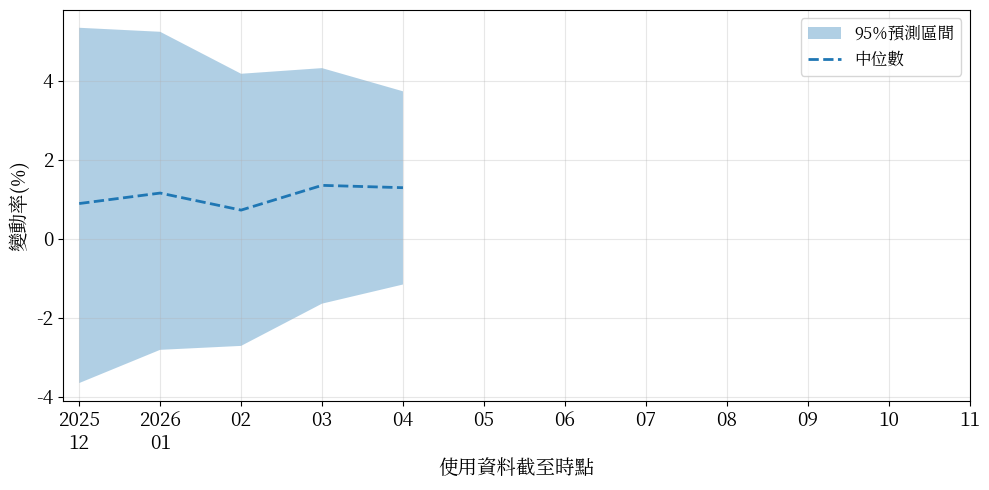

--------------------------------------開始 seafood 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=478.870, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=453.005, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=455.923, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=478.722, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=482.219, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=446.388, Time=0.16 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=428.902, Time=0.49 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=425.139, Time=0.18 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=462.046, Time=0.05 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=427.596, Time=0.33 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=466.972, Time=0.14 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=inf, Time=0.53 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=437.121, Time=0.12 sec
 ARIMA(2,1,0)

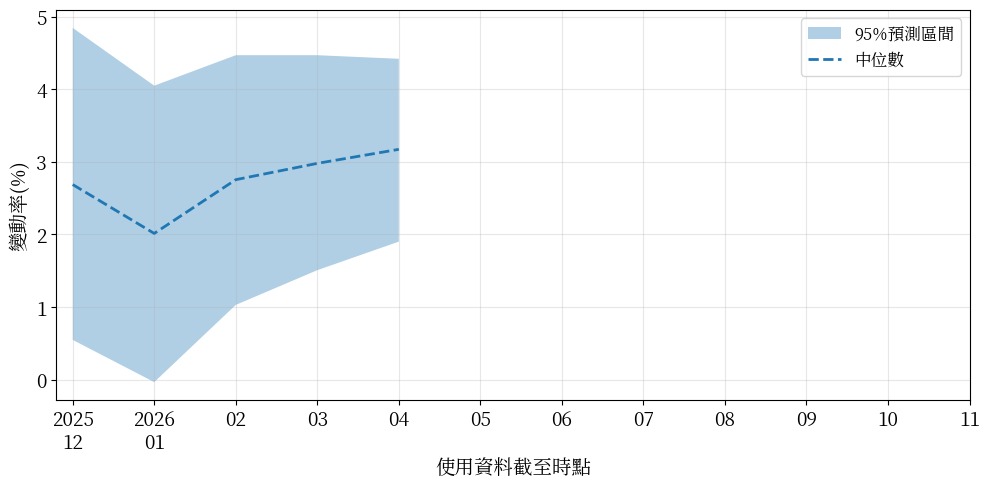

--------------------------------------開始 eggs 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=892.669, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=892.081, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=895.118, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=887.908, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=887.366, Time=0.03 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : BIC=883.392, Time=0.08 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : BIC=878.841, Time=0.16 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=874.869, Time=0.08 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=890.799, Time=0.04 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : BIC=878.765, Time=0.21 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : BIC=889.358, Time=0.14 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : BIC=883.872, Time=0.33 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=879.758, Time=0.12 sec
 ARIMA(0,1,1

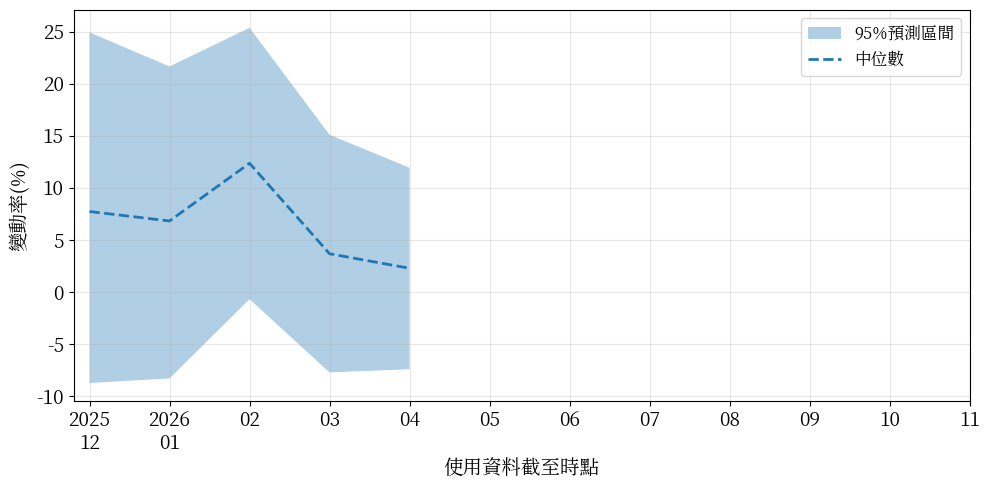

--------------------------------------開始 egg 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=945.029, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=944.346, Time=0.06 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=947.459, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=940.175, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=939.593, Time=0.03 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : BIC=935.680, Time=0.09 sec
 ARIMA(0,1,0)(2,0,1)[12] intercept   : BIC=930.944, Time=0.16 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=926.991, Time=0.08 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=943.061, Time=0.04 sec
 ARIMA(0,1,0)(1,0,2)[12] intercept   : BIC=930.849, Time=0.22 sec
 ARIMA(0,1,0)(0,0,2)[12] intercept   : BIC=941.737, Time=0.14 sec
 ARIMA(0,1,0)(2,0,2)[12] intercept   : BIC=936.016, Time=0.33 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=931.915, Time=0.12 sec
 ARIMA(0,1,1)

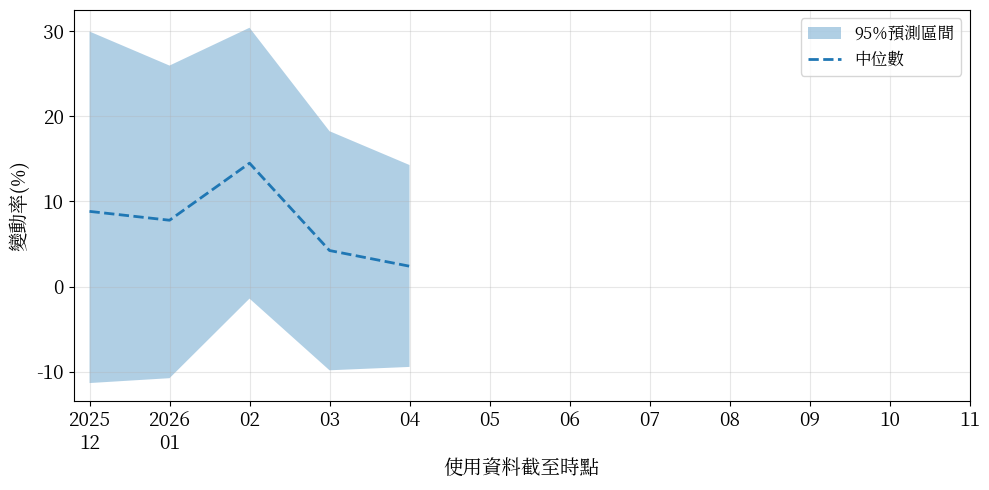

--------------------------------------開始 dairy 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=302.643, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=295.400, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=300.613, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=300.347, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=307.537, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=298.503, Time=0.16 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=295.156, Time=0.13 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=300.087, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=298.320, Time=0.46 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=298.234, Time=0.41 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=298.997, Time=0.15 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=inf, Time=0.64 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=295.768, Time=0.13 sec
 ARIMA(2,1,0)(1

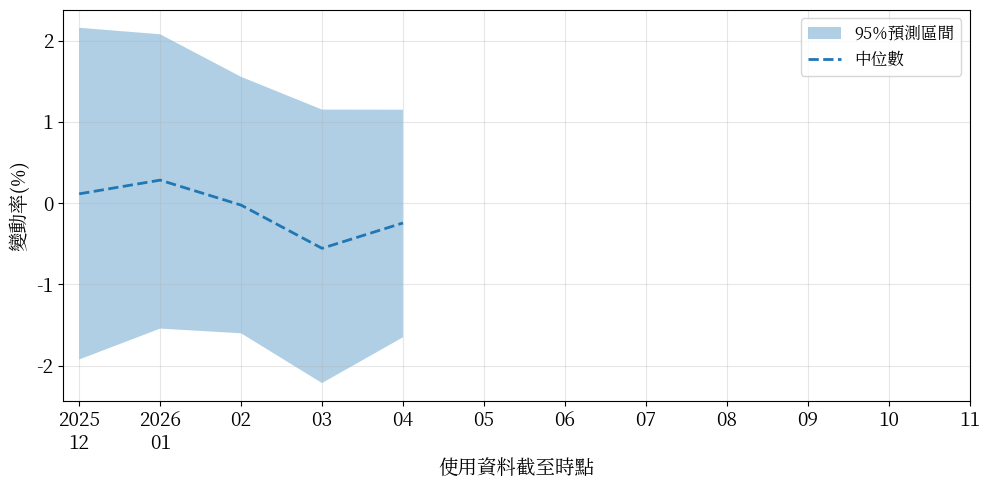

--------------------------------------開始 milk 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=487.542, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=474.072, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=482.578, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=483.654, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=490.526, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=474.259, Time=0.13 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=470.390, Time=0.09 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=482.476, Time=0.04 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=474.093, Time=0.40 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=474.163, Time=0.33 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=477.158, Time=0.14 sec
 ARIMA(1,1,0)(2,0,2)[12] intercept   : BIC=479.053, Time=0.65 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=469.040, Time=0.08 sec
 ARIMA(0,1,0

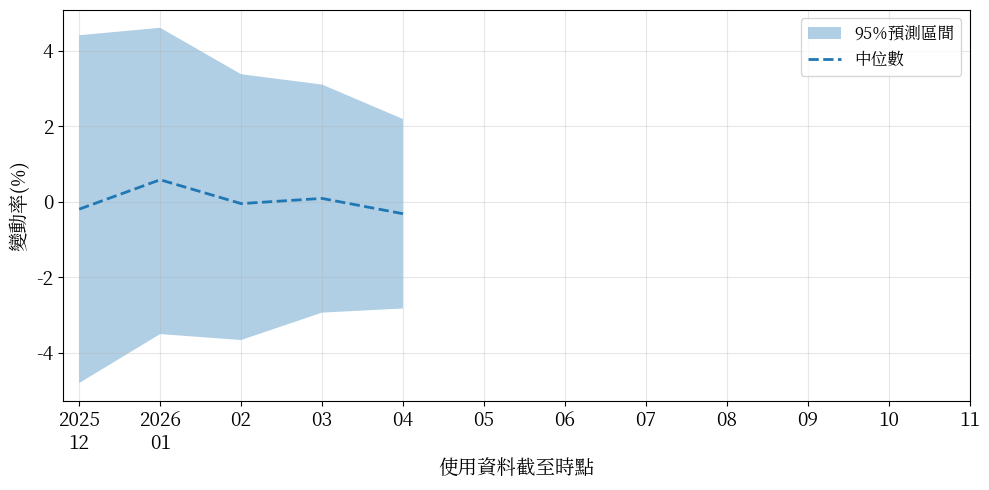

--------------------------------------開始 vegetable 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=1097.425, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=1092.483, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=1093.288, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=1092.619, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=1096.000, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : BIC=1095.385, Time=0.21 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.15 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=1094.159, Time=0.08 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=inf, Time=0.49 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=1092.160, Time=0.05 sec
 ARIMA(0,1,0)(2,0,0)[12] intercept   : BIC=1093.626, Time=0.11 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.15 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=1094.619, Time=0.05 sec
 ARIMA(0,

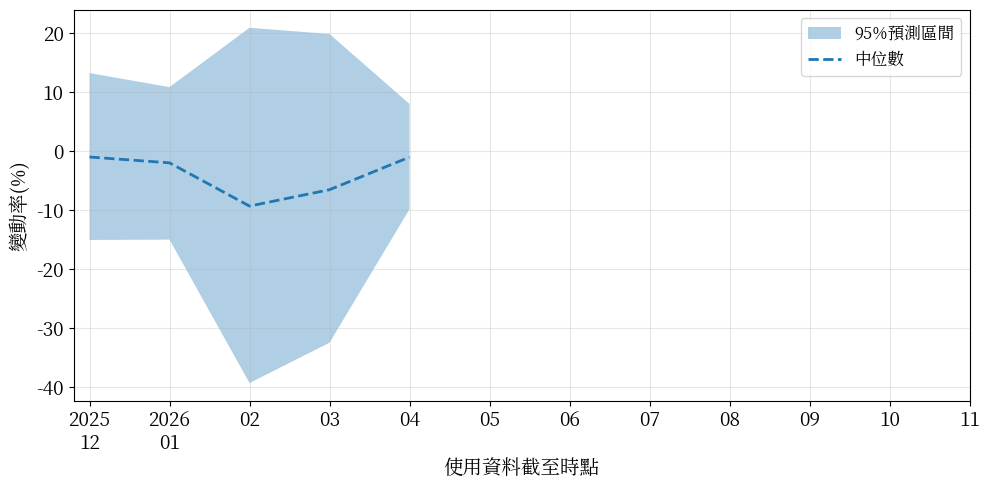

--------------------------------------開始 fruit 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=886.354, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=883.499, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=880.215, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=881.912, Time=0.01 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : BIC=876.447, Time=0.02 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : BIC=879.470, Time=0.05 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : BIC=inf, Time=0.29 sec
 ARIMA(1,1,1)(0,0,0)[12] intercept   : BIC=880.954, Time=0.02 sec
 ARIMA(0,1,2)(0,0,0)[12] intercept   : BIC=880.689, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=880.424, Time=0.02 sec
 ARIMA(1,1,2)(0,0,0)[12] intercept   : BIC=876.936, Time=0.06 sec
 ARIMA(0,1,1)(0,0,0)[12]             : BIC=871.796, Time=0.01 sec
 ARIMA(0,1,1)(1,0,0)[12]             : BIC=874.743, Time=0.02 sec
 ARIMA(0,1,1)(0

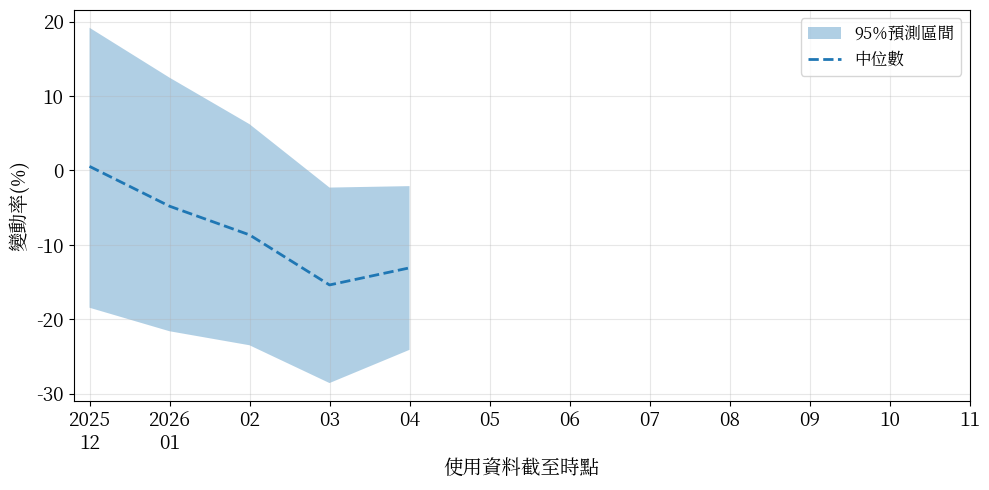

--------------------------------------開始 oils 預測--------------------------------------
Performing stepwise search to minimize bic
 ARIMA(0,1,0)(0,0,0)[12] intercept   : BIC=446.066, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : BIC=446.077, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : BIC=445.469, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[12]             : BIC=444.963, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : BIC=446.799, Time=0.03 sec
 ARIMA(0,1,0)(0,0,1)[12] intercept   : BIC=447.993, Time=0.03 sec
 ARIMA(0,1,0)(1,0,1)[12] intercept   : BIC=inf, Time=0.21 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : BIC=444.599, Time=0.01 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : BIC=447.105, Time=0.03 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : BIC=437.058, Time=0.15 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : BIC=438.076, Time=0.37 sec
 ARIMA(1,1,0)(1,0,2)[12] intercept   : BIC=436.736, Time=0.24 sec
 ARIMA(1,1,0)(0,0,2)[12] intercept   : BIC=446.434, Time=0.13 sec
 ARIMA(1,1,0)(2,

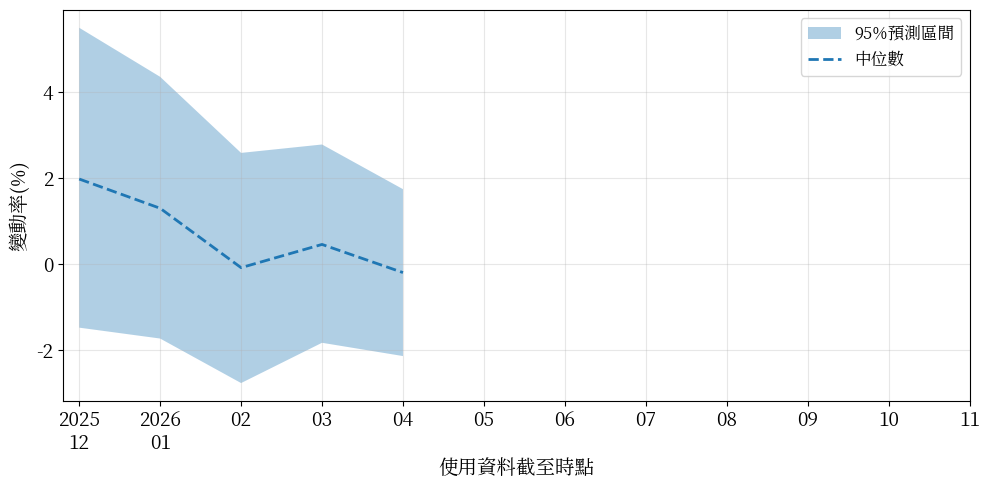

In [15]:
# 設定日期
end_date = pd.to_datetime('2025-12-1')
forecast_date = pd.to_datetime('2026-12-1')
n = 5
for item in cols.values():
    print(f'--------------------------------------開始 {item} 預測--------------------------------------')
    summary_df, summary_yoy_df, actual_yoy, summary_month_d = get_result(y=item, end_date=end_date, forecast_date=forecast_date, n=n)
    plot_result(summary_yoy_df, actual_yoy=actual_yoy)